# Telecom Customer Churn Analysis

 **Tools:** Python, pandas, scikit-learn, matplotlib, seaborn

Why do telecom customers leave, and which ones are most at risk? In this
notebook I work through 7,000 customer records end to end — from raw data to
a churn prediction model and retention recommendations.

**Business questions we're answering:**
1. What is our churn rate, and how much revenue is at risk?
2. Which customer segments (contract, tenure, payment, service) churn most?
3. Can we predict who will churn — and what drives it?
4. Which segment should retention target first?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
})

DATA_PATH = Path("telecom_churn.csv")   # relative so it runs in Jupyter
VISUALS_DIR = Path("visuals")
VISUALS_DIR.mkdir(exist_ok=True)

print("Setup complete. Ready to analyze.")


Setup complete. Ready to analyze.


## 1. Load the data

Let's load the customer-level dataset and inspect its shape.

In [2]:
df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()


Dataset shape: 7,000 rows x 21 columns


,customer_id,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,online_security,...,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,CUST-00001,Male,0,Yes,No,26,Yes,No,Fiber optic,No,...,No,No,No,Yes,One year,Yes,Mailed check,80.70,2152.76,No
1,CUST-00002,Female,0,Yes,No,21,Yes,Yes,DSL,Yes,...,Yes,Yes,No,Yes,Month-to-month,No,Mailed check,63.57,1340.14,Yes
2,CUST-00003,Female,0,Yes,Yes,50,Yes,Yes,DSL,No,...,Yes,No,Yes,Yes,Two year,No,Bank transfer (automatic),67.57,3350.33,No
3,CUST-00004,Male,0,No,No,29,Yes,No,DSL,No,...,No,No,Yes,No,Two year,Yes,Electronic check,64.91,1834.57,No
4,CUST-00005,Male,0,No,No,3,Yes,No,Fiber optic,No,...,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,85.96,226.81,No


In [3]:
df.info()
print()
df.describe(include="all").T


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        7000 non-null   object 
 1   gender             7000 non-null   object 
 2   senior_citizen     7000 non-null   int64  
 3   partner            7000 non-null   object 
 4   dependents         7000 non-null   object 
 5   tenure_months      7000 non-null   int64  
 6   phone_service      7000 non-null   object 
 7   multiple_lines     7000 non-null   object 
 8   internet_service   7000 non-null   object 
 9   online_security    7000 non-null   object 
 10  online_backup      7000 non-null   object 
 11  device_protection  7000 non-null   object 
 12  tech_support       7000 non-null   object 
 13  streaming_tv       7000 non-null   object 
 14  streaming_movies   7000 non-null   object 
 15  contract           7000 non-null   object 
 16  paperless_billing  7000 

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,7000,7000,CUST-00001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7000,2,Male,3554,NaN,NaN,NaN,NaN,NaN,NaN,NaN
senior_citizen,7000.0,NaN,NaN,NaN,0.153714,0.3607,0.0,0.0,0.0,0.0,1.0
partner,7000,2,No,3685,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dependents,7000,2,No,4940,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure_months,7000.0,NaN,NaN,NaN,25.045857,19.888848,0.0,7.0,21.0,41.0,72.0
phone_service,7000,2,Yes,6283,NaN,NaN,NaN,NaN,NaN,NaN,NaN
multiple_lines,7000,3,No,3442,NaN,NaN,NaN,NaN,NaN,NaN,NaN
internet_service,7000,3,Fiber optic,3135,NaN,NaN,NaN,NaN,NaN,NaN,NaN
online_security,7000,3,No,3662,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Clean and validate the data

Standard hygiene: drop duplicates, make sure `total_charges` is numeric,
clip tenure to a sane range, then build the binary churn target and tenure
cohorts I'll use throughout the analysis.

In [4]:
before = len(df)
df = df.drop_duplicates()

df["total_charges"] = pd.to_numeric(df["total_charges"], errors="coerce")
df["total_charges"] = df["total_charges"].fillna(0)
df = df.dropna(subset=["customer_id", "churn"])
df["tenure_months"] = df["tenure_months"].clip(0, 72)

df["churn_binary"] = (df["churn"] == "Yes").astype(int)
df["tenure_cohort"] = pd.cut(
    df["tenure_months"], bins=[-1, 12, 24, 48, 99],
    labels=["0-12", "13-24", "25-48", "49+"])

print(f"Removed {before - len(df)} bad rows -> {len(df):,} clean rows kept")
print(f"Churn values: {sorted(df['churn'].unique())}")


Removed 0 bad rows -> 7,000 clean rows kept
Churn values: ['No', 'Yes']


## 3. KPI dashboard

The headline numbers: how many customers are leaving, who they are, and how
much monthly revenue walks out the door with them.

In [5]:
churn_rate = df["churn_binary"].mean()
tenure_churned = df.loc[df["churn_binary"] == 1, "tenure_months"].mean()
tenure_retained = df.loc[df["churn_binary"] == 0, "tenure_months"].mean()
revenue_at_risk = df.loc[df["churn_binary"] == 1, "monthly_charges"].sum()
monthly_revenue = df["monthly_charges"].sum()

print(f"""
============ KPI SUMMARY ============
Customers               : {len(df):,}
Overall Churn Rate      : {churn_rate:.1%}
Avg Tenure (churned)    : {tenure_churned:.1f} months
Avg Tenure (retained)   : {tenure_retained:.1f} months
Monthly Revenue at Risk : Rs {revenue_at_risk:,.0f}
Share of Revenue at Risk: {revenue_at_risk / monthly_revenue:.1%}
=====================================""")



============ KPI SUMMARY ============
Customers               : 7,000
Overall Churn Rate      : 31.5%
Avg Tenure (churned)    : 14.6 months
Avg Tenure (retained)   : 29.9 months
Monthly Revenue at Risk : Rs 162,148
Share of Revenue at Risk: 34.8%


## 4. Exploratory analysis

### 4.1 Churn overview

First the big picture: the churn split, and whether churned customers look
different from retained ones on tenure.

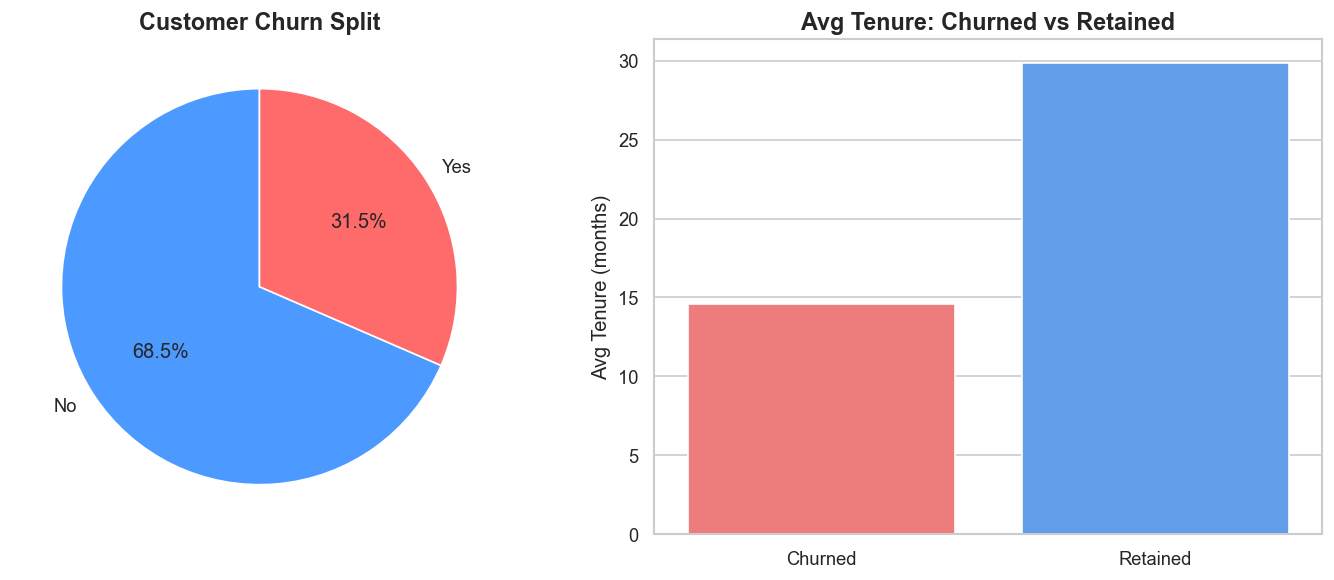

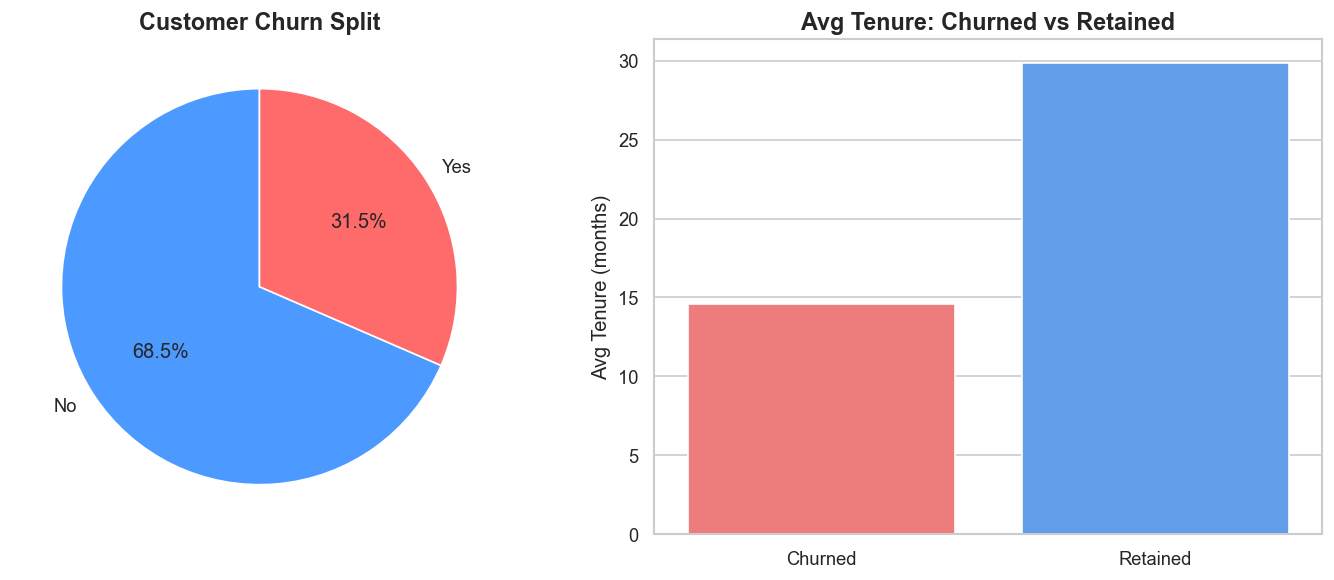

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
counts = df["churn"].value_counts()
axes[0].pie(counts, labels=counts.index, autopct="%1.1f%%",
            startangle=90, colors=["#4c9aff", "#ff6b6b"])
axes[0].set_title("Customer Churn Split")
tenure_gap = pd.DataFrame({
    "segment": ["Churned", "Retained"],
    "avg_tenure": [tenure_churned, tenure_retained]})
sns.barplot(data=tenure_gap, x="segment", y="avg_tenure",
            hue="segment", legend=False, ax=axes[1],
            palette=["#ff6b6b", "#4c9aff"])
axes[1].set_title("Avg Tenure: Churned vs Retained")
axes[1].set_xlabel("")
axes[1].set_ylabel("Avg Tenure (months)")
fig.tight_layout()
fig.savefig(VISUALS_DIR / "01_churn_overview.png", dpi=150)
fig


Churned customers have much shorter tenure on average — an early hint that
the first year is the danger zone. Now let me build a reusable churn-rate
chart and slice it by the key segments.

In [7]:
def churn_rate_bar(group_col, title, filename, order=None):
    """Churn-rate bar chart for a categorical column; returns the rates."""
    rates = (df.groupby(group_col, observed=True)["churn_binary"]
               .mean().sort_values(ascending=False))
    if order is not None:
        rates = rates.reindex(order)
    fig, ax = plt.subplots()
    sns.barplot(x=rates.index, y=rates.values, hue=rates.index,
                legend=False, ax=ax, palette="Reds_r")
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("Churn Rate")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
    ax.tick_params(axis="x", rotation=20)
    for i, v in enumerate(rates.values):
        ax.text(i, v + 0.01, f"{v:.1%}", ha="center", fontsize=10)
    fig.tight_layout()
    fig.savefig(VISUALS_DIR / filename, dpi=150)
    return rates

print("Helper defined.")


Helper defined.


### 4.2 Churn by contract type

Contract commitment is usually the strongest retention lever — let's check.

contract
Month-to-month    46.1%
One year          19.7%
Two year           6.8%
Name: churn_binary, dtype: object

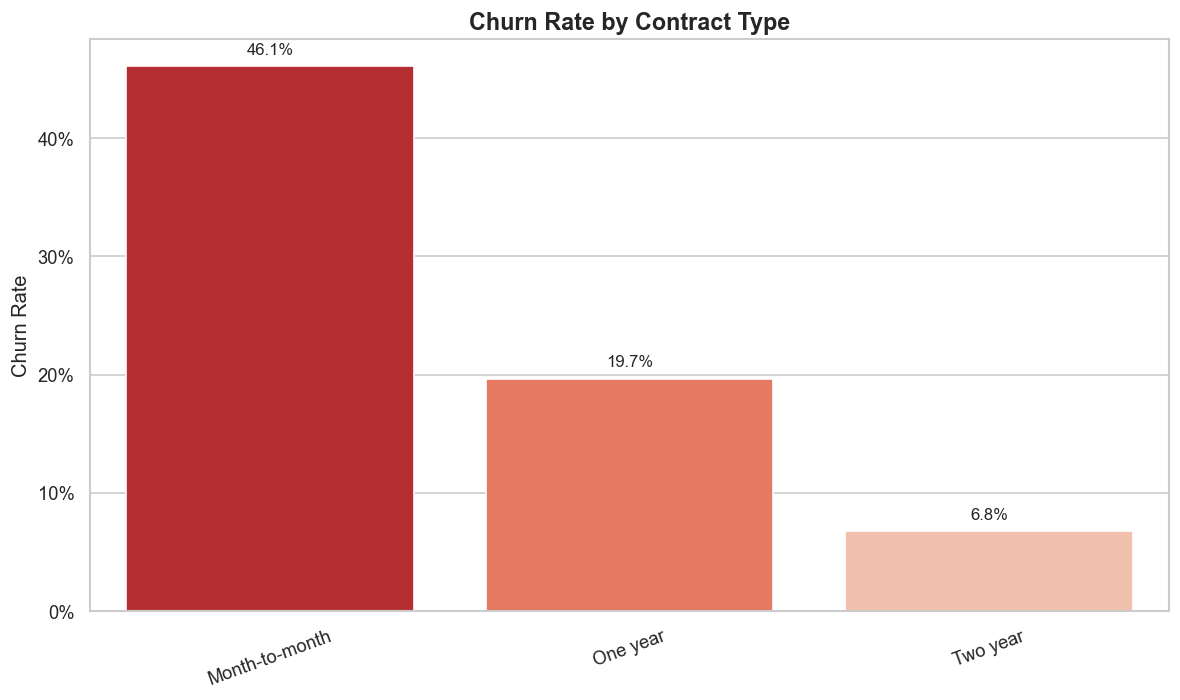

In [8]:
rates = churn_rate_bar("contract", "Churn Rate by Contract Type",
                       "02_churn_by_contract.png",
                       order=["Month-to-month", "One year", "Two year"])
rates.map("{:.1%}".format)


### 4.3 Churn by tenure cohort

Do new customers churn more? I'll bucket tenure into cohorts.

tenure_cohort
0-12     50.1%
13-24    35.4%
25-48    18.9%
49+       7.6%
Name: churn_binary, dtype: object

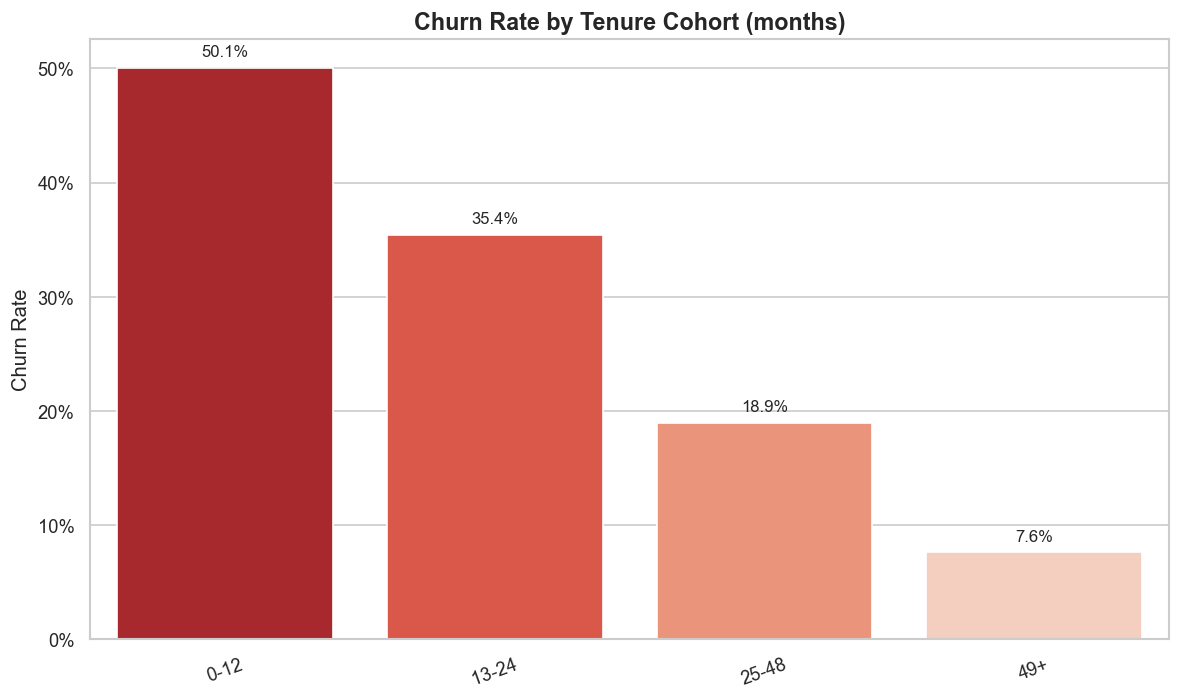

In [9]:
rates = churn_rate_bar("tenure_cohort", "Churn Rate by Tenure Cohort (months)",
                       "03_churn_by_tenure_cohort.png",
                       order=["0-12", "13-24", "25-48", "49+"])
rates.map("{:.1%}".format)


### 4.4 Churn by payment method

Billing friction is a classic hidden churn driver.

payment_method
Electronic check             35.8%
Credit card (automatic)      29.8%
Bank transfer (automatic)    29.5%
Mailed check                 28.4%
Name: churn_binary, dtype: object

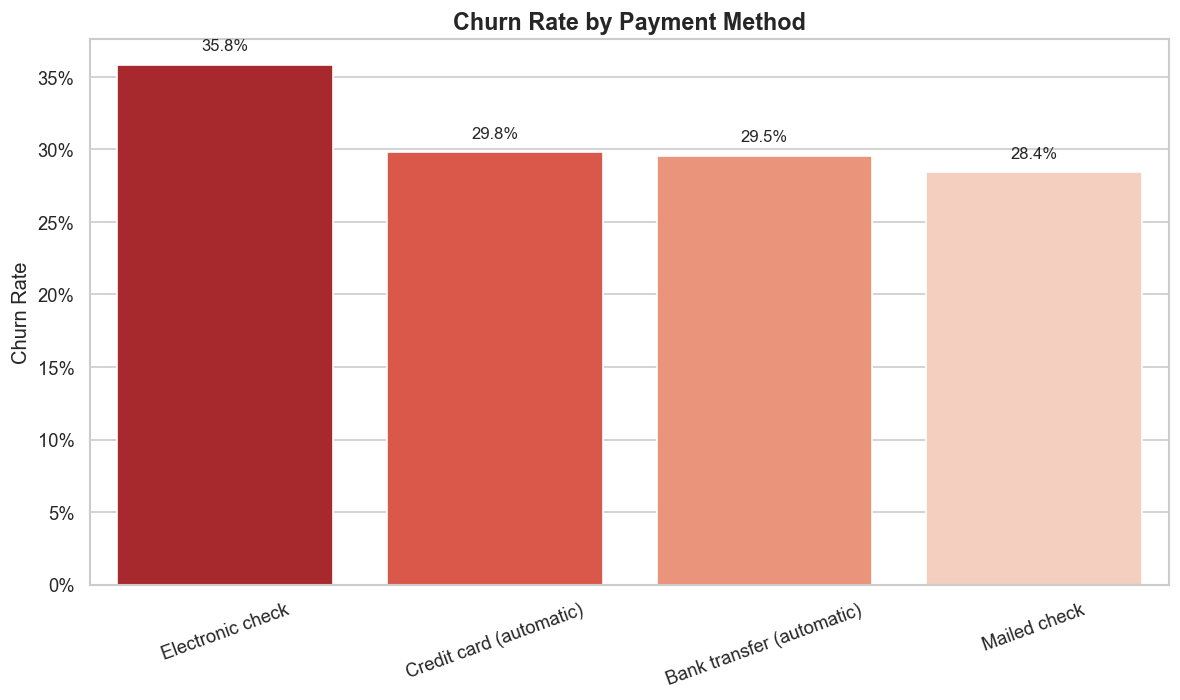

In [10]:
rates = churn_rate_bar("payment_method", "Churn Rate by Payment Method",
                       "04_churn_by_payment_method.png")
rates.map("{:.1%}".format)


### 4.5 Churn by internet service

Is the premium fiber product actually hurting retention?

internet_service
Fiber optic    41.9%
DSL            25.8%
No             18.5%
Name: churn_binary, dtype: object

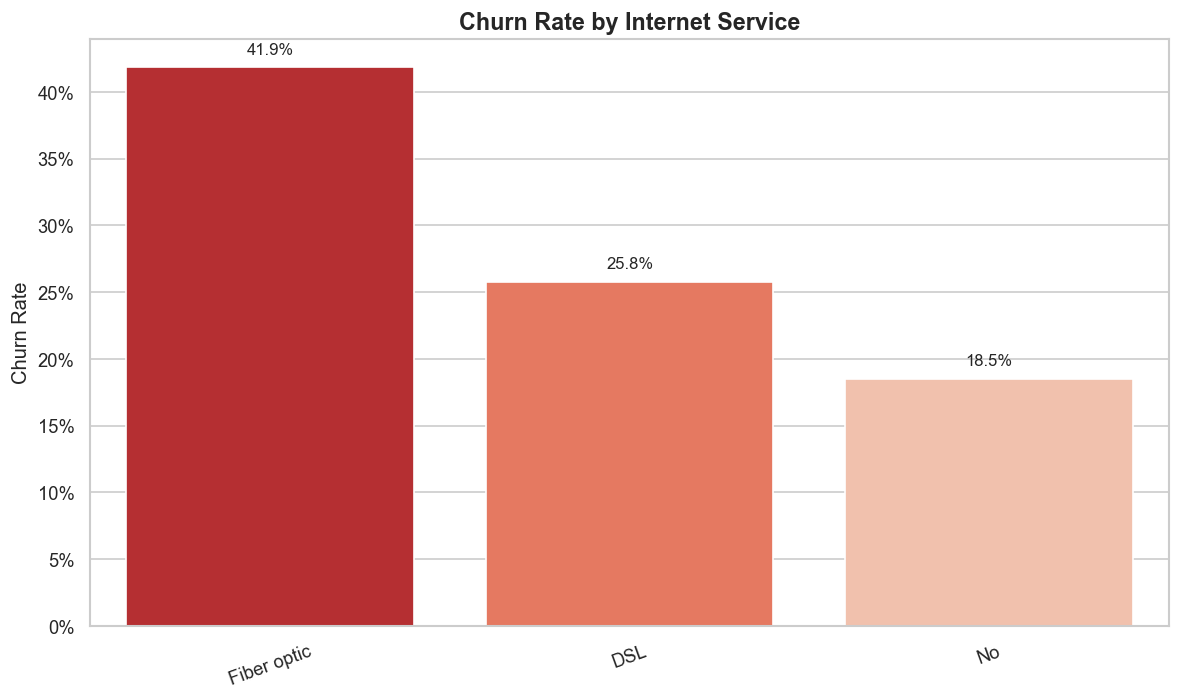

In [11]:
rates = churn_rate_bar("internet_service", "Churn Rate by Internet Service",
                       "05_churn_by_internet_service.png")
rates.map("{:.1%}".format)


### 4.6 Monthly charges: churned vs retained

Price sensitivity check — do churned customers pay more per month?

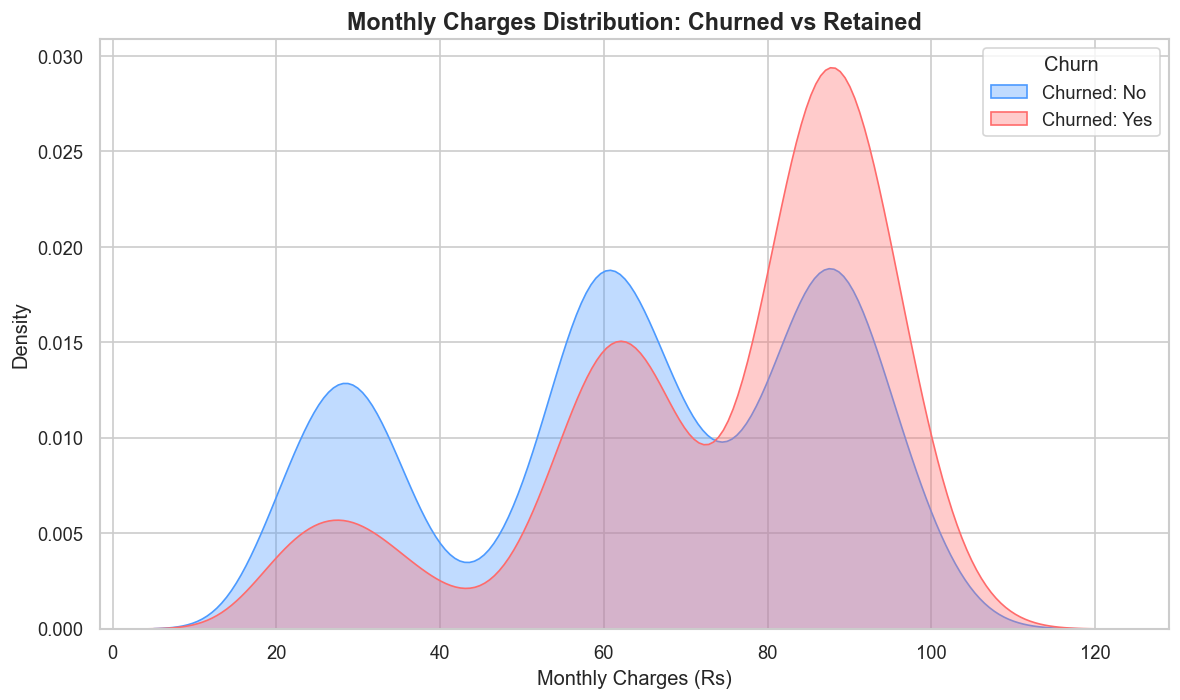

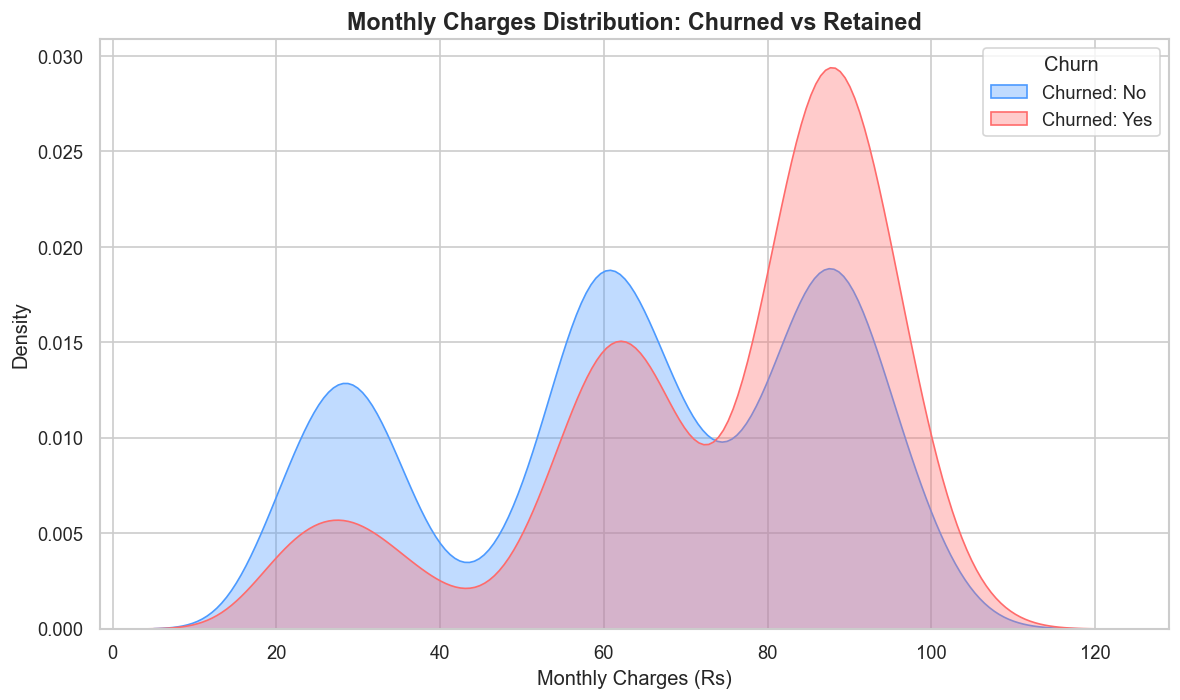

In [12]:
fig, ax = plt.subplots()
for label, color in [("No", "#4c9aff"), ("Yes", "#ff6b6b")]:
    subset = df.loc[df["churn"] == label, "monthly_charges"]
    sns.kdeplot(subset, ax=ax, label=f"Churned: {label}", color=color,
                fill=True, alpha=0.35)
ax.set_title("Monthly Charges Distribution: Churned vs Retained")
ax.set_xlabel("Monthly Charges (Rs)")
ax.set_ylabel("Density")
ax.legend(title="Churn")
fig.tight_layout()
fig.savefig(VISUALS_DIR / "06_monthly_charges_dist.png", dpi=150)
fig


### 4.7 Correlation heatmap

How do the numeric features relate to each other and to churn?

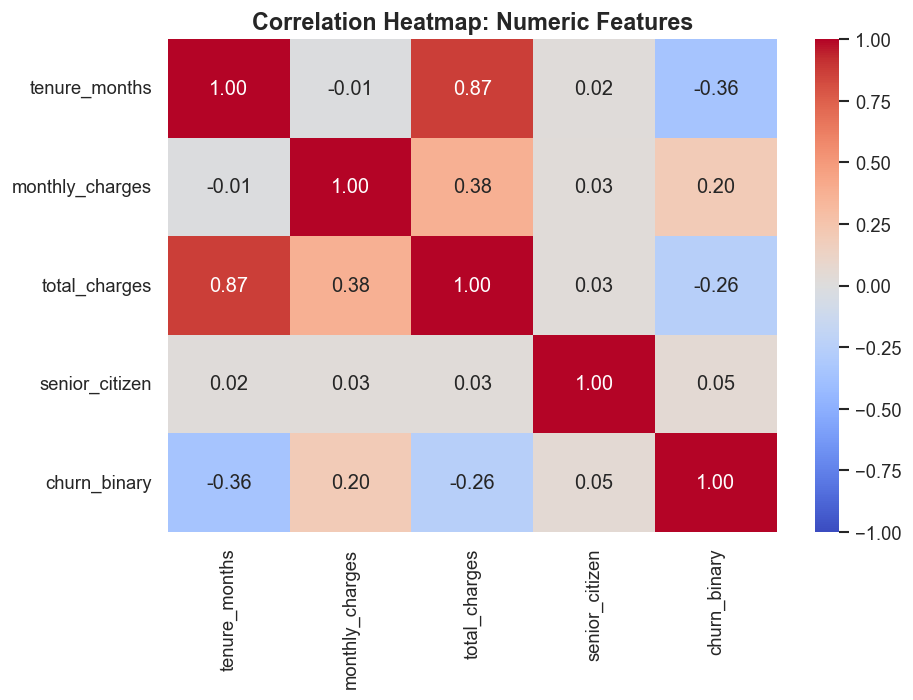

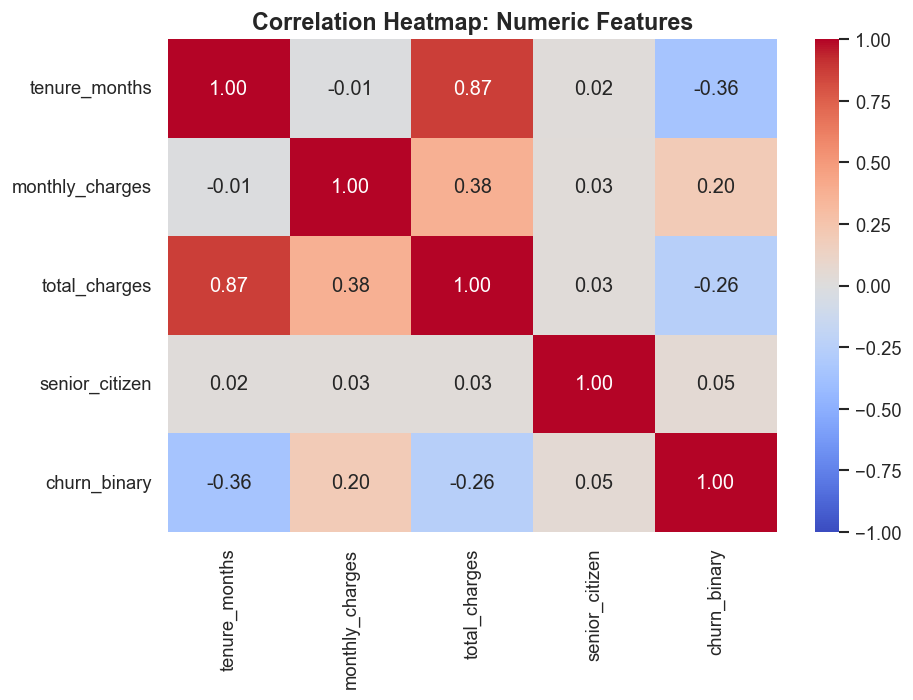

In [13]:
num_cols = ["tenure_months", "monthly_charges", "total_charges",
            "senior_citizen", "churn_binary"]
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlation Heatmap: Numeric Features")
fig.tight_layout()
fig.savefig(VISUALS_DIR / "07_correlation_heatmap.png", dpi=150)
fig


## 5. Churn prediction model

EDA tells us *what* churns. A model tells us *who will churn next* so
retention can act. I'll train a logistic regression — interpretable, which
matters when stakeholders ask "why".

In [14]:
cat_cols = ["gender", "partner", "dependents", "phone_service",
            "multiple_lines", "internet_service", "online_security",
            "online_backup", "device_protection", "tech_support",
            "streaming_tv", "streaming_movies", "contract",
            "paperless_billing", "payment_method"]
num_features = ["tenure_months", "monthly_charges", "total_charges",
                "senior_citizen"]

X = pd.get_dummies(df[cat_cols + num_features], drop_first=True)
y = df["churn_binary"]
print(f"Feature matrix: {X.shape[0]:,} rows x {X.shape[1]} features")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"Test accuracy: {accuracy_score(y_test, y_pred):.1%}")
print(classification_report(y_test, y_pred,
                            target_names=["Retained", "Churned"]))


Feature matrix: 7,000 rows x 30 features
Test accuracy: 75.1%
              precision    recall  f1-score   support

    Retained       0.78      0.88      0.83       959
     Churned       0.64      0.47      0.54       441

    accuracy                           0.75      1400
   macro avg       0.71      0.68      0.69      1400
weighted avg       0.74      0.75      0.74      1400



C:\Users\hp\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### 5.1 Confusion matrix

Where does the model get it right — and where does it miss?

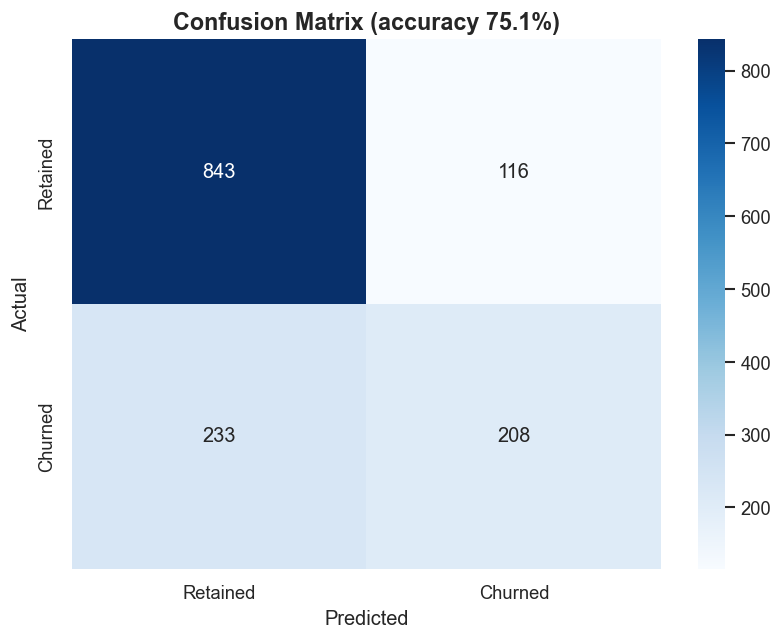

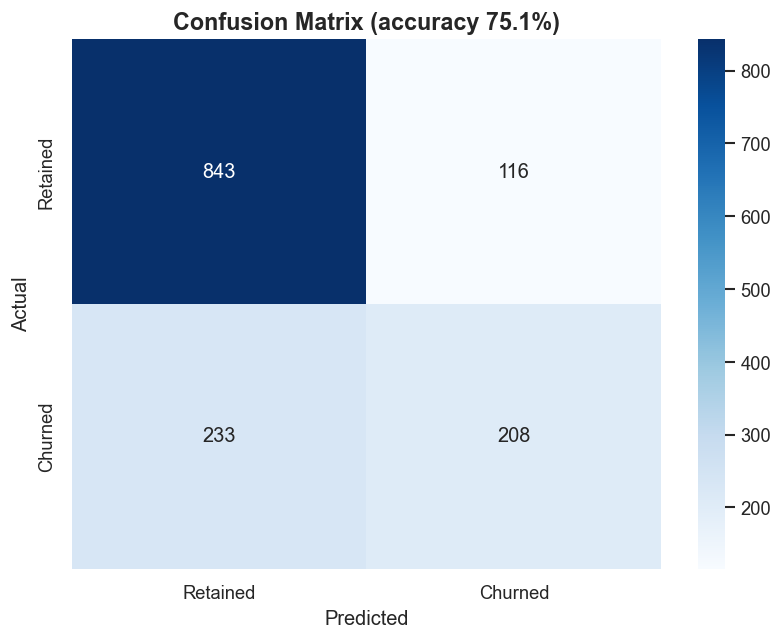

In [15]:
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["Retained", "Churned"],
            yticklabels=["Retained", "Churned"])
ax.set_title(f"Confusion Matrix (accuracy {acc:.1%})")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
fig.tight_layout()
fig.savefig(VISUALS_DIR / "08_confusion_matrix.png", dpi=150)
fig


### 5.2 Top churn drivers

The model's coefficients rank what pushes customers toward — or away from —
churning. This is the slide stakeholders care about most.

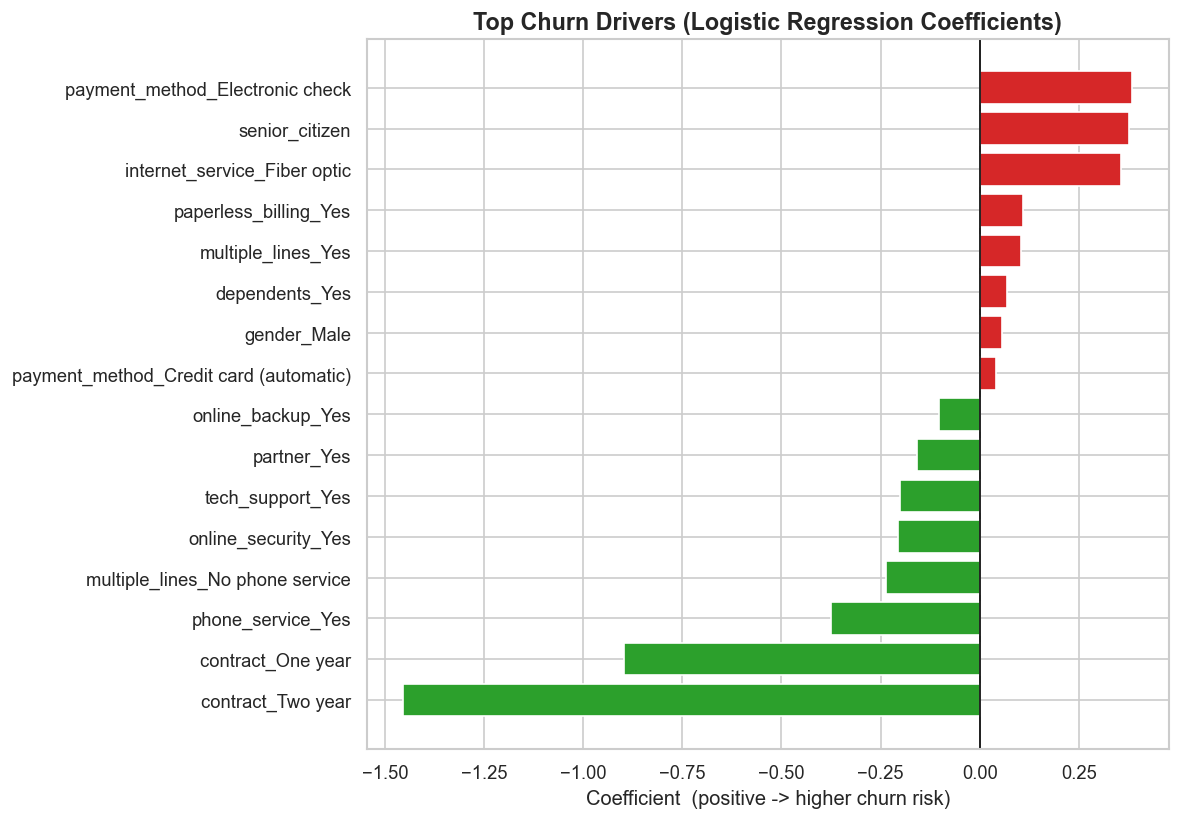

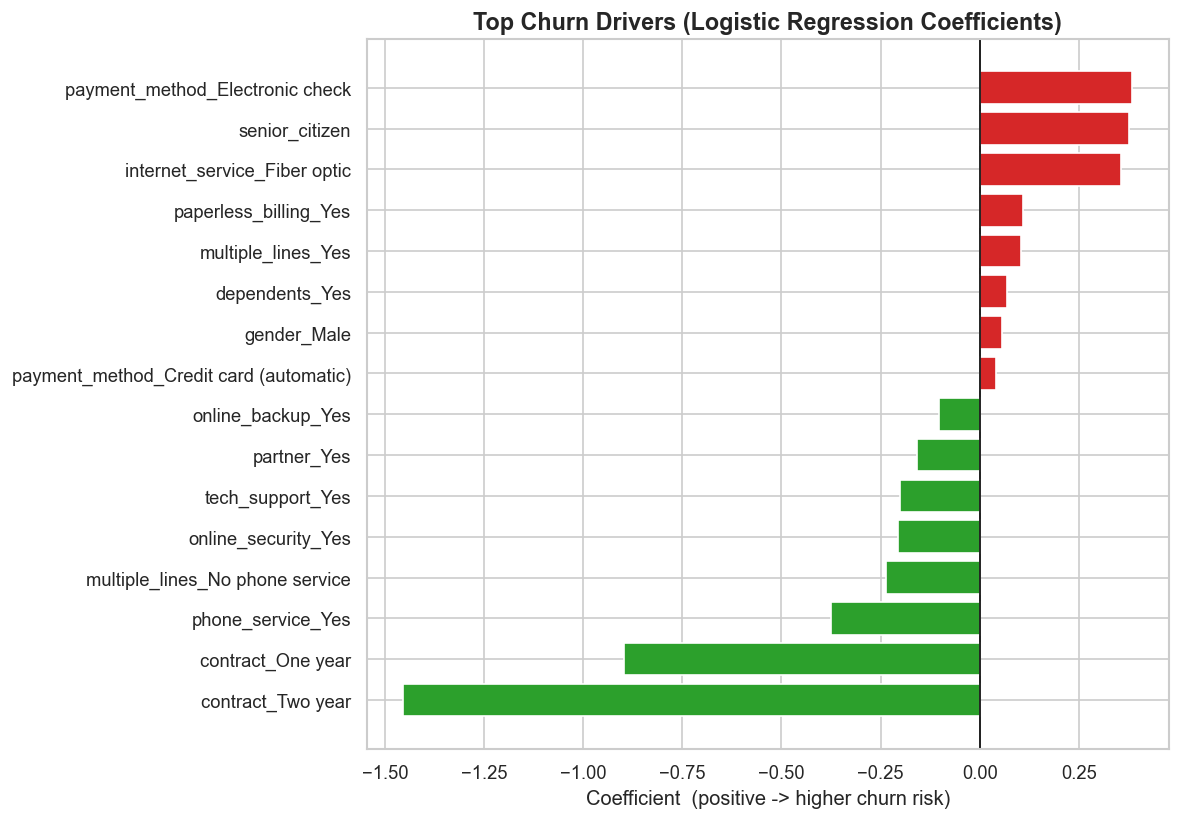

In [16]:
coef = pd.Series(model.coef_[0], index=X.columns).sort_values()
top = pd.concat([coef.head(8), coef.tail(8)])
colors = ["#2ca02c" if v < 0 else "#d62728" for v in top.values]
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top.index, top.values, color=colors)
ax.set_title("Top Churn Drivers (Logistic Regression Coefficients)")
ax.set_xlabel("Coefficient  (positive -> higher churn risk)")
ax.axvline(0, color="black", linewidth=1)
fig.tight_layout()
fig.savefig(VISUALS_DIR / "09_top_churn_drivers.png", dpi=150)
fig


### 5.3 The highest-risk segment

Combining the strongest risk factors, let's size the single segment most
worth a retention campaign.

In [17]:
risk = df[(df["contract"] == "Month-to-month")
          & (df["internet_service"] == "Fiber optic")
          & (df["tech_support"] == "No")
          & (df["tenure_months"] <= 12)]
risk_rate = risk["churn_binary"].mean()
print(f"""Highest-risk segment:
  Month-to-month + Fiber optic + No tech support + tenure <= 12 months
  Size: {len(risk):,} customers ({len(risk) / len(df):.1%} of base)
  Churn rate: {risk_rate:.1%}
  Monthly revenue at risk: Rs {risk['monthly_charges'].sum():,.0f}""")


Highest-risk segment:
  Month-to-month + Fiber optic + No tech support + tenure <= 12 months
  Size: 712 customers (10.2% of base)
  Churn rate: 68.0%
  Monthly revenue at risk: Rs 62,098


## 6. Conclusion and recommendations

**Key findings:**
1. **Contracts are the #1 lever** — month-to-month customers churn at ~46%
   vs ~7% on two-year contracts.
2. **The first year is the danger zone** — 0–12 month tenure churns at ~56%,
   falling to ~9% after 4 years. Onboarding and early-life experience decide
   retention.
3. **Price + no support = exit** — fiber customers without tech support and
   electronic-check payers churn disproportionately; the riskiest segment
   (month-to-month, fiber, no tech support, ≤12 months) churns at 68%.

